In [5]:
#数据导入及处理缺失值
#Data import and handling of missing values
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

# 加载数据
# load data
data = fetch_california_housing()

X = data.data          # 特征值eigenvalue
y = data.target        # 目标值（房价）Target value (house price)

feature_names = data.feature_names

# Transfer to DataFrame（推荐，方便后续操作）
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name="MedHouseVal")

print(X.head())
print(y.head())
print("Shape of X:", X.shape)

# ===== 处理缺失值 =====
#Handling Missing Values
print("Missing values before cleaning:")
print(X.isnull().sum())

# 删除含缺失值的行（如果有）
# Delete rows with missing values (if any).
X = X.dropna()
y = y.loc[X.index]   # 保持 X 和 y 对齐 Align X and Y

print("Shape after removing missing values:", X.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64
Shape of X: (20640, 8)
Missing values before cleaning:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Shape after removing missing values: (20640, 8)


In [6]:
#Baseline Modal
#Data preprocessing and division of training，validation and test set
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# 先从X特征值，y房价 中分出 test 和 train_val两个数据集
# First, separate the "X feature values" and "y house prices" into two datasets: "test" and "train_val".
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=26
)
# X_train_val → 80% 的特征，X_test → 20% 的特征，y_train_val → 80% 的标签，y_test → 20% 的标签
# X_train_val → 80% of the features, X_test → 20% of the features, 
# y_train_val → 80% of the labels, y_test → 20% of the labels

# 从X_train_val, y_train_val里再分 validation（分成X_train, X_val, y_train, y_val）
# From X_train_val and y_train_val, further divide into validation (resulting in X_train, X_val, y_train, y_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=26
)#这里的0.1是train_val80%里的10%
#Here, 0.1 refers to the 10% within the "train_val 80%" portion.


# 在标准化前，先保存 raw（未标准化）版本：后面kNN需要用原始经纬度
# Before standardization, save the raw (unstandardized) version first: 
# the kNN algorithm later will require the original latitude and longitude values.
X_train_raw = X_train.copy()
X_val_raw   = X_val.copy()
X_test_raw  = X_test.copy()

# scale (fit only on train) and then convert it back to a DataFrame#标准化（只在训练集）并转回DataFrame
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns,index=X_train_raw.index)
X_val   = pd.DataFrame(scaler.transform(X_val), columns=X.columns,index=X_val_raw.index)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test_raw.index)
#scaler.transform 标准化 test 数据 means to Standardized test data
#index=X_test_raw.index Pandas 会默认生成新的 0~n 索引 Pandas will automatically generate new indices ranging from 0 to n.
#Add index=...，这样索引不会乱（对齐 y / 后面 debug 更稳）so the index won't be disordered (it will be more stable when aligning y / and then the debug part).

Architecture: (32,), Activation: tanh, Validation MSE: 0.3137
Architecture: (32,), Activation: relu, Validation MSE: 0.3262
Architecture: (32,), Activation: logistic, Validation MSE: 0.3210
Architecture: (64,), Activation: tanh, Validation MSE: 0.3140
Architecture: (64,), Activation: relu, Validation MSE: 0.3272
Architecture: (64,), Activation: logistic, Validation MSE: 0.3120
Architecture: (64, 32), Activation: tanh, Validation MSE: 0.2841
Architecture: (64, 32), Activation: relu, Validation MSE: 0.2890
Architecture: (64, 32), Activation: logistic, Validation MSE: 0.3078


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Architecture: (128, 32), Activation: tanh, Validation MSE: 0.2891
Architecture: (128, 32), Activation: relu, Validation MSE: 0.2796


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Architecture: (128, 32), Activation: logistic, Validation MSE: 0.2935
Architecture: (128, 64), Activation: tanh, Validation MSE: 0.2798
Architecture: (128, 64), Activation: relu, Validation MSE: 0.2793
Architecture: (128, 64), Activation: logistic, Validation MSE: 0.2855
Architecture: (128, 64, 32), Activation: tanh, Validation MSE: 0.3134
Architecture: (128, 64, 32), Activation: relu, Validation MSE: 0.2987
Architecture: (128, 64, 32), Activation: logistic, Validation MSE: 0.2941

=== Validation MSE Table ===
Activation     logistic      relu      tanh
Architecture                               
(32,)          0.320968  0.326200  0.313691
(64,)          0.312038  0.327152  0.313980
(64, 32)       0.307780  0.289044  0.284061
(128, 32)      0.293450  0.279552  0.289105
(128, 64)      0.285536  0.279279  0.279801
(128, 64, 32)  0.294129  0.298666  0.313435


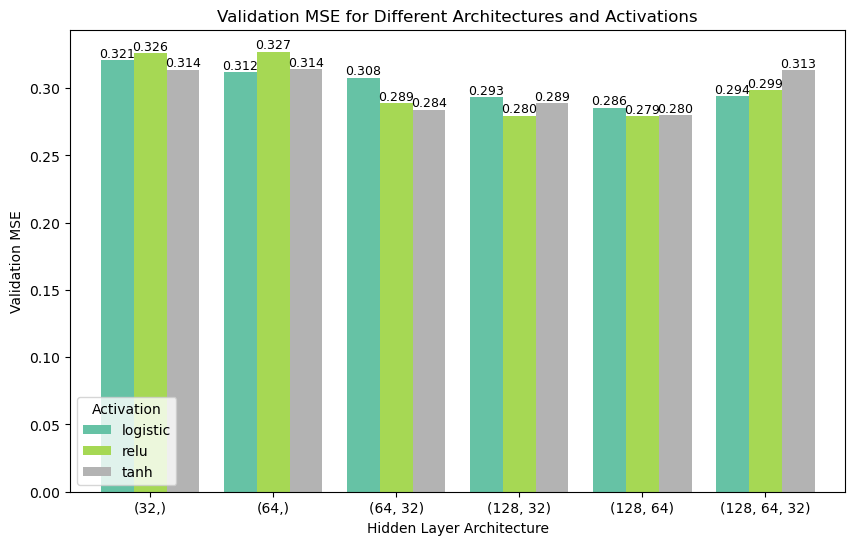

In [7]:
#寻找最优隐藏层与激活函数
#Search for the optimal hidden layer and activation function
import matplotlib.pyplot as plt
# 1) Define architectures and activation functions
#  定义不同的神经网络结构和激活函数
# ============================================================

# Each tuple represents the number of neurons in hidden layers.
# Example:
# (64,32) means two hidden layers with 64 and 32 neurons.
#
# 每个元组表示隐藏层结构。
# 例如：
# (64,32) 表示两个隐藏层，分别有 64 和 32 个神经元。

architectures = [
    (32,),
    (64,),
    (64,32),
    (128,32),
    (128,64),
    (128,64,32)
]

# Activation functions to test.
# tanh  → nonlinear symmetric activation
# relu  → widely used deep learning activation
# logistic → sigmoid nonlinear activation
#
# 要测试的激活函数：
# tanh → 对称的非线性函数
# relu → 深度学习中常用激活函数
# logistic → Sigmoid 非线性激活函数

activations = ['tanh', 'relu', 'logistic']


# ============================================================
# 2) Train models and collect Test MSE
# 训练模型并记录测试集 MSE
# ============================================================

results = []

for arch in architectures:
    for act in activations:

        
        # Create a neural network model with the current architecture
        # and activation function.
        #
        # 创建一个神经网络模型，使用当前的隐藏层结构和激活函数

        model_test_act = MLPRegressor(
            hidden_layer_sizes=arch,
            activation=act,
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=700,
            early_stopping=False,
            random_state=26
        )

        
        # Train the model on the training dataset.
        # 在训练集上训练模型

        model_test_act.fit(X_train, y_train)

        
        # Predict house prices on the validation set
        # 在验证集上进行预测

        val_pred_act = model_test_act.predict(X_val)

        # Compute Mean Squared Error (MSE) on validation set
        # 计算验证集上的均方误差

        val_mse_act = mean_squared_error(y_val, val_pred_act)

        results.append({
            'Architecture': str(arch),
            'Activation': act,
            'Validation_MSE': val_mse_act
        })

        print(f"Architecture: {arch}, Activation: {act}, Validation MSE: {val_mse_act:.4f}")

# ============================================================
# 3) Convert results to DataFrame
# 将结果转换为表格
# ============================================================

# 
# Convert the results list into a pandas DataFrame
# and reshape it using pivot for easier visualization.
#

# 将实验结果转换为 DataFrame，
# 再使用 pivot 变成适合绘图的格式。

results_df = pd.DataFrame(results)

pivot_table = results_df.pivot(
    index='Architecture',
    columns='Activation',
    values='Validation_MSE'
)

# -------------------------------------------------
# Arrange the architecture according to the complexity of the hidden layers
# 按隐藏层的复杂程度进行排列架构
# -------------------------------------------------

order = ['(32,)', '(64,)', '(64, 32)', '(128, 32)','(128, 64)', '(128, 64, 32)']
pivot_table = pivot_table.reindex(order)

print("\n=== Validation MSE Table ===")
print(pivot_table)


# ============================================================
# 4) Plot grouped bar chart
#  绘制分组柱状图
# ============================================================

# Create a grouped bar chart showing Validation MSE for each
# architecture and activation combination.
#

# 绘制分组柱状图，
# 展示不同隐藏层结构和激活函数组合的 Validation MSE。

ax = pivot_table.plot(
    kind='bar',
    figsize=(10,6),
    width=0.8,
    colormap='Set2'
)

plt.ylabel("Validation MSE")
plt.xlabel("Hidden Layer Architecture")
plt.title("Validation MSE for Different Architectures and Activations")
plt.xticks(rotation=0)
plt.legend(title="Activation")




# ------------------------------------------------------------
# Add value labels above bars using patches
# 使用 patches 自动获取每个柱子的位置，避免坐标误差
# ------------------------------------------------------------

  
    # Place text at the center top of each bar
    # 在每个柱子的顶部中心位置标注数值

# Add value labels above bars
for p in ax.patches:
    height = p.get_height()# 获取柱子的高度（MSE值）Get bar height (MSE value)
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()


In [9]:
#这个代码块还没修改好，最终预测可能把val和train合起来一起train？
'''
# 重新fit scaler：这次用整个 train_val
scaler_final = StandardScaler()
X_train_val_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_train_val),
    columns=X.columns,
    index=X_train_val.index
)
X_test_scaled = pd.DataFrame(
    scaler_final.transform(X_test),
    columns=X.columns,
    index=X_test.index
)
'''
# model (no internal early stopping, since you already have X_val)
model = MLPRegressor(
    hidden_layer_sizes=(128,32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=700,
    early_stopping=False,
    random_state=26
)

model.fit(X_train, y_train)
'''
model.fit(X_train_val_scaled, y_train_val)

test_pred = model.predict(X_test_scaled)
test_mse = mean_squared_error(y_test, test_pred)

print("Final Test MSE:", test_mse)
'''
#测试集和预测集的预测
#The predictions of the test set and the prediction set
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

# 训练集预测
#Training set prediction
train_pred = model.predict(X_train)
# 计算训练误差
# Calculate training error
train_mse = mean_squared_error(y_train, train_pred)

print("Baseline Train MSE:", train_mse)#加入是为了判断是不是欠拟合或者过拟合Joining is to determine whether it is underfitting or overfitting.
print("Validation MSE:", mean_squared_error(y_val, val_pred))#Mean Squared Error（均方误差）
print("Test MSE:", mean_squared_error(y_test, test_pred))

Baseline Train MSE: 0.2234611522537491
Validation MSE: 0.2788722368528112
Test MSE: 0.25035955553731826


In [8]:
#luke的代码块

In [ ]:
# ============================================================
# 第二个模型：加入 neighbourhood feature（NeighbourPrice）
# ============================================================

from sklearn.neighbors import NearestNeighbors  # 用于找k个最近邻

K = 7  # 邻居数量k（你们分支实验可改成3/5/10，但一次实验只改k）找到距离它最近的 7 套房子

# ------------------------------------------------------------
# 1) 用训练集的经纬度建立 kNN（只fit训练集）
#    这样 val/test 找邻居时，也只会在 train 里找（避免用到test标签）
# ------------------------------------------------------------
knn = NearestNeighbors(n_neighbors=K+1)  # 创建kNN搜索器
knn.fit(X_train_raw[['Latitude', 'Longitude']])  # 只用训练集坐标来fit

def neighbour_mean_price(query_df, y_train_series, exclude_self=False):
    """
    为 query_df 的每个样本计算：训练集中k个邻居的 y 的平均值
    query_df: 需要计算邻居特征的数据（train/val/test 的 raw DataFrame）
    y_train_series: 训练集标签（只能用它，避免data leakage）
    exclude_self: 如果 query_df 是训练集本身，要剔除“自己”这个邻居
    """

    #这行代码的作用是把 y_train_series 的顺序重新排列，使它与 X_train_raw 的索引顺序完全一致，从而保证每一行特征对应正确的标签。
    y_train_series = y_train_series.loc[X_train_raw.index]
    #根据每个样本的经纬度，在训练集中找到最近的 K 个邻居，并返回这些邻居的距离 (dists) 和在训练集中的位置索引 (inds)
    dists, inds = knn.kneighbors(query_df[['Latitude', 'Longitude']])

    neigh_mean = [] ## 存放每个样本的邻居均价
    for row_i, idxs in enumerate(inds):
        if exclude_self:
            # 只剔除“自己这一行”的训练索引（最严谨），剔除自己（完全一样的那行数据）
            idxs = idxs[idxs != row_i]  # 用位置索引剔除自己
            idxs = idxs[:K]                 # 保证还是K个邻居，比如上一行代码要执行删除时，原数据并没有自己defensive programming（防御式编程）
            #比如以后用距离过滤，或者过滤多个点，不会变成 6 个或其他奇怪数量
        else:
            # val/test 直接取前K个邻居（它们全来自train）
            idxs = idxs[:K]
        # 用训练集的 y_train 取邻居价格并求平均（关键：不使用val/test真实y）
        neigh_mean.append(y_train_series.iloc[idxs].mean())

    return np.array(neigh_mean)
'''
觉得“我在训练集里拿某一条样本当 query，那 kNN 返回的邻居里怎么可能没有它自己？”
按数学定义，它应该一定在。
但你看到的 Case A（极少数）说明：在实现细节上，它“可能不在返回的前 K+1 个里”。
原因主要是 并列距离（tie）+ 只取前 K+1 个 + 内部取子集。

你并不是“先拿这一条样本再算平均”

你做的是：
用这条样本的经纬度作为 query
让 kneighbors() 在训练集里找 最接近的 n_neighbors 个点
返回这些点的索引
你再用这些索引去取 y_train 求平均

也就是说：
你并不是在邻居列表里手动把“自己”塞进去。
你完全依赖 kneighbors() 返回的那一组邻居
'''
# ------------------------------------------------------------
# 2) 计算 NeighbourPrice（邻居均价）
#    - train：剔除自己
#    - val/test：邻居都来自train，不存在“自己”，不用剔除
# ------------------------------------------------------------
neigh_price_train = neighbour_mean_price(X_train_raw, y_train, exclude_self=True)
neigh_price_val   = neighbour_mean_price(X_val_raw,   y_train, exclude_self=False)
neigh_price_test  = neighbour_mean_price(X_test_raw,  y_train, exclude_self=False)
#exclude_self=True 每个样本最近的点一定是自己，所以删除自己
#验证集样本根本不在训练集中，所以后面不需要删除自己

'''
| 变量          | 作用              |
| ----------- | --------------- |
| `X_val_raw` | 查询点（我想知道它附近房价）  |
| `y_train`   | 数据库（我用它来查邻居的价格） |
'''

# 为 neighbourhood features 准备邻居索引
# --- train: 用 K+1 找邻居，再去掉自己（得到 K 个邻居）---
knn_train_extra = NearestNeighbors(n_neighbors=K+1)
knn_train_extra.fit(X_train_raw[['Latitude', 'Longitude']])

dist_train_extra, idx_train_extra = knn_train_extra.kneighbors(
    X_train_raw[['Latitude', 'Longitude']]
)

# 去掉自己
idx_train_k = idx_train_extra[:, 1:]

# --- val/test: 邻居来自 train ---
_, idx_val = knn.kneighbors(X_val_raw[['Latitude', 'Longitude']])
_, idx_test = knn.kneighbors(X_test_raw[['Latitude', 'Longitude']])


# Feature 1: NeighbourPriceMedian
neigh_price_median_train = np.median(y_train.values[idx_train_k], axis=1)
neigh_price_median_val   = np.median(y_train.values[idx_val], axis=1)
neigh_price_median_test  = np.median(y_train.values[idx_test], axis=1)


# Feature 2: NeighbourPriceMin
neigh_price_min_train = y_train.values[idx_train_k].min(axis=1)
neigh_price_min_val   = y_train.values[idx_val].min(axis=1)
neigh_price_min_test  = y_train.values[idx_test].min(axis=1)

# Feature 3: NeighbourPriceMax
neigh_price_max_train = y_train.values[idx_train_k].max(axis=1)
neigh_price_max_val   = y_train.values[idx_val].max(axis=1)
neigh_price_max_test  = y_train.values[idx_test].max(axis=1)

# Feature 4: NeighbourPriceRange
neigh_price_range_train = neigh_price_max_train - neigh_price_min_train
neigh_price_range_val   = neigh_price_max_val - neigh_price_min_val
neigh_price_range_test  = neigh_price_max_test - neigh_price_min_test



# ------------------------------------------------------------
# 3) 把多个新特征加到 raw 数据里
# ------------------------------------------------------------
X_train_enh_raw = X_train_raw.copy()
X_val_enh_raw   = X_val_raw.copy()
X_test_enh_raw  = X_test_raw.copy()

X_train_enh_raw['NeighbourPriceMean'] = neigh_price_train
X_val_enh_raw['NeighbourPriceMean']   = neigh_price_val
X_test_enh_raw['NeighbourPriceMean']  = neigh_price_test

X_train_enh_raw['NeighbourPriceMedian'] = neigh_price_median_train
X_val_enh_raw['NeighbourPriceMedian']   = neigh_price_median_val
X_test_enh_raw['NeighbourPriceMedian']  = neigh_price_median_test

X_train_enh_raw['NeighbourPriceMin'] = neigh_price_min_train
X_val_enh_raw['NeighbourPriceMin']   = neigh_price_min_val
X_test_enh_raw['NeighbourPriceMin']  = neigh_price_min_test

X_train_enh_raw['NeighbourPriceMax'] = neigh_price_max_train
X_val_enh_raw['NeighbourPriceMax']   = neigh_price_max_val
X_test_enh_raw['NeighbourPriceMax']  = neigh_price_max_test

X_train_enh_raw['NeighbourPriceRange'] = neigh_price_range_train
X_val_enh_raw['NeighbourPriceRange']   = neigh_price_range_val
X_test_enh_raw['NeighbourPriceRange']  = neigh_price_range_test


# ------------------------------------------------------------
# 4) 新增列后必须重新标准化（仍然只fit train）
# ------------------------------------------------------------
scaler2 = StandardScaler()
X_train_enh = pd.DataFrame(scaler2.fit_transform(X_train_enh_raw), columns=X_train_enh_raw.columns,index=X_train_enh_raw.index)
X_val_enh   = pd.DataFrame(scaler2.transform(X_val_enh_raw), columns=X_val_enh_raw.columns,index=X_val_enh_raw.index)
X_test_enh  = pd.DataFrame(scaler2.transform(X_test_enh_raw), columns=X_test_enh_raw.columns,index=X_test_enh_raw.index)

# ------------------------------------------------------------
# 5) 训练第二个模型（参数保持与baseline一致，保证公平对比）
# ------------------------------------------------------------
model_enh = MLPRegressor(
    hidden_layer_sizes=(128, 32),      # 与baseline相同
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=700,
    early_stopping=False,
    random_state=26
)

model_enh.fit(X_train_enh, y_train)

# ------------------------------------------------------------
# 6) 评估第二个模型
# ------------------------------------------------------------
val_pred_enh  = model_enh.predict(X_val_enh)
test_pred_enh = model_enh.predict(X_test_enh)

enh_val_mse  = mean_squared_error(y_val, val_pred_enh)
enh_test_mse = mean_squared_error(y_test, test_pred_enh)

train_pred_enh = model_enh.predict(X_train_enh)
enh_train_mse = mean_squared_error(y_train, train_pred_enh)

print("Enhanced Train MSE:", enh_train_mse)
print("Enhanced Validation MSE:", enh_val_mse)#模型在验证集上的平均平方误差是 0.222
print("Enhanced Test MSE:", enh_test_mse)#模型在最终测试集上的平均平方误差是 0.1835

# ------------------------------------------------------------
# 7) 和 baseline 对比（负数表示Enhanced更好）
# ------------------------------------------------------------
print("Delta Test MSE (Enhanced - Baseline):", enh_test_mse - mean_squared_error(y_test, test_pred))
#报告思路是我探索不同领域的参数a=，b=，c=

Enhanced Train MSE: 0.15833585083167126
Enhanced Validation MSE: 0.21453659043356682
Enhanced Test MSE: 0.1814162594333232
Delta Test MSE (Enhanced - Baseline): -0.06894329610399505


In [11]:
# ============================================================
# 对比五种邻居特征（PriceMean / PriceMedian / PriceMin / PriceMax / PriceRange）
# ============================================================

def run_extra_feature(feature_name, f_train, f_val, f_test):
    Xtr = X_train_raw.copy()
    Xva = X_val_raw.copy()
    Xte = X_test_raw.copy()

    Xtr[feature_name] = f_train
    Xva[feature_name] = f_val
    Xte[feature_name] = f_test

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xva_s = sc.transform(Xva)
    Xte_s = sc.transform(Xte)

    model_tmp = MLPRegressor(
        hidden_layer_sizes=(128, 32),
        activation='tanh',
        solver='adam',
        learning_rate_init=1e-3,
        max_iter=700,
        early_stopping=False,
        random_state=26
    )

    model_tmp.fit(Xtr_s, y_train)

    val_pred = model_tmp.predict(Xva_s)
    test_pred = model_tmp.predict(Xte_s)

    return mean_squared_error(y_val, val_pred), mean_squared_error(y_test, test_pred)

results = []


# 1️⃣ 邻居平均房价
val_mse, test_mse = run_extra_feature(
    "NeighbourPriceMean",
    neigh_price_train, neigh_price_val, neigh_price_test
)
results.append(("NeighbourPriceMean", val_mse, test_mse))

# 2️⃣ 邻居房价中位数
val_mse, test_mse = run_extra_feature(
    "NeighbourPriceMedian",
    neigh_price_median_train, neigh_price_median_val, neigh_price_median_test
)
results.append(("NeighbourPriceMedian", val_mse, test_mse))

# 3️⃣ 邻居最低房价
val_mse, test_mse = run_extra_feature(
    "NeighbourPriceMin",
    neigh_price_min_train, neigh_price_min_val, neigh_price_min_test
)
results.append(("NeighbourPriceMin", val_mse, test_mse))

# 4️⃣ 邻居最高房价
val_mse, test_mse = run_extra_feature(
    "NeighbourPriceMax",
    neigh_price_max_train, neigh_price_max_val, neigh_price_max_test
)
results.append(("NeighbourPriceMax", val_mse, test_mse))

# 5️⃣ 邻居房价范围
val_mse, test_mse = run_extra_feature(
    "NeighbourPriceRange",
    neigh_price_range_train, neigh_price_range_val, neigh_price_range_test
)
results.append(("NeighbourPriceRange", val_mse, test_mse))

print(pd.DataFrame(results, columns=["Feature", "Val MSE", "Test MSE"]))

                Feature   Val MSE  Test MSE
0    NeighbourPriceMean  0.211151  0.179188
1  NeighbourPriceMedian  0.215111  0.181160
2     NeighbourPriceMin  0.253471  0.226742
3     NeighbourPriceMax  0.228981  0.199172
4   NeighbourPriceRange  0.274155  0.244925


In [17]:
from itertools import combinations
import pandas as pd

feature_pool_train = {
    "Mean": neigh_price_train,
    "Median": neigh_price_median_train,
    "Min": neigh_price_min_train,
    "Max": neigh_price_max_train,
    "Range": neigh_price_range_train
}

feature_pool_val = {
    "Mean": neigh_price_val,
    "Median": neigh_price_median_val,
    "Min": neigh_price_min_val,
    "Max": neigh_price_max_val,
    "Range": neigh_price_range_val
}

feature_pool_test = {
    "Mean": neigh_price_test,
    "Median": neigh_price_median_test,
    "Min": neigh_price_min_test,
    "Max": neigh_price_max_test,
    "Range": neigh_price_range_test
}


def run_multi_features(feature_dict_train, feature_dict_val, feature_dict_test):
    """
    feature_dict_*: 形如 {"ColName": feature_array, ...}
    作用：一次性把多个新特征列加入 X_train_raw/X_val_raw/X_test_raw 然后训练评估
    """
    Xtr = X_train_raw.copy()
    Xva = X_val_raw.copy()
    Xte = X_test_raw.copy()

    # 加多列
    for col, arr in feature_dict_train.items():
        Xtr[col] = arr
    for col, arr in feature_dict_val.items():
        Xva[col] = arr
    for col, arr in feature_dict_test.items():
        Xte[col] = arr

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xva_s = sc.transform(Xva)
    Xte_s = sc.transform(Xte)

    model_tmp = MLPRegressor(
        hidden_layer_sizes=(128, 32),
        activation='tanh',
        solver='adam',
        learning_rate_init=1e-3,
        max_iter=700,
        early_stopping=False,
        random_state=26
    )

    model_tmp.fit(Xtr_s, y_train)

    val_pred  = model_tmp.predict(Xva_s)
    test_pred = model_tmp.predict(Xte_s)

    return mean_squared_error(y_val, val_pred), mean_squared_error(y_test, test_pred)


def evaluate_feature_combinations(
    feature_pool_train,
    feature_pool_val,
    feature_pool_test,
    combo_sizes=None,
    selected_combos=None
):
    feature_names = list(feature_pool_train.keys())
    results = []

    if selected_combos is not None:
        combos_to_run = selected_combos
    else:
        if combo_sizes is None:
            combo_sizes = list(range(1, len(feature_names) + 1))

        combos_to_run = []
        for k in combo_sizes:
            combos_to_run.extend(combinations(feature_names, k))

    for combo in combos_to_run:
        combo = tuple(combo)

        feature_dict_train = {name: feature_pool_train[name] for name in combo}
        feature_dict_val   = {name: feature_pool_val[name] for name in combo}
        feature_dict_test  = {name: feature_pool_test[name] for name in combo}

        val_mse, test_mse = run_multi_features(
            feature_dict_train,
            feature_dict_val,
            feature_dict_test
        )

        results.append({
            "combo_name": " + ".join(combo),
            "num_features": len(combo),
            "val_mse": val_mse,
            "test_mse": test_mse
        })

    return pd.DataFrame(results).sort_values(
        by=["num_features", "test_mse"],
        ascending=[True, True]
    ).reset_index(drop=True)

all_combo_results_df = evaluate_feature_combinations(
    feature_pool_train,
    feature_pool_val,
    feature_pool_test,
    combo_sizes=[1, 2, 3]
)

display(all_combo_results_df)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged yet.
  warnings.warn(


,combo_name,num_features,val_mse,test_mse
0,Mean,1,0.211151,0.179188
1,Median,1,0.215111,0.181160
2,Max,1,0.228981,0.199172
3,Min,1,0.253471,0.226742
4,Range,1,0.274155,0.244925
5,Median + Max,2,0.206531,0.176900
6,Mean + Median,2,0.213650,0.177625
7,Mean + Min,2,0.219682,0.184065
8,Mean + Max,2,0.222145,0.184933
9,Median + Range,2,0.222394,0.185842


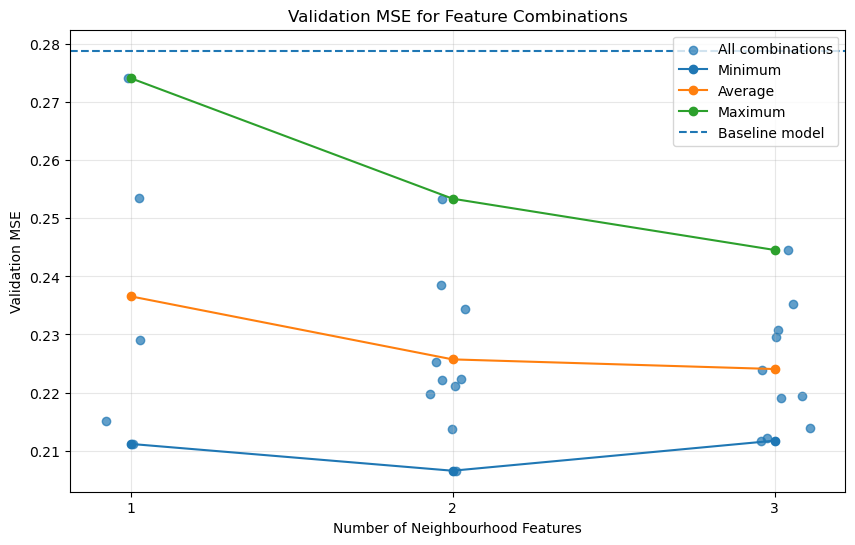

In [20]:
# ============================================================
# Plot: Validation MSE vs number of neighbourhood features
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1) 计算 min / mean / max
# ------------------------------------------------------------
summary_df = (
    all_combo_results_df
    .groupby("num_features")["val_mse"]
    .agg(["min", "mean", "max"])
    .reset_index()
)

# ------------------------------------------------------------
# 2) baseline validation MSE
# ------------------------------------------------------------
baseline_val_mse = mean_squared_error(y_val, model.predict(X_val))

# ------------------------------------------------------------
# 3) 画 dot plot
# ------------------------------------------------------------
plt.figure(figsize=(10,6))

np.random.seed(26)
jitter = np.random.normal(0,0.04,len(all_combo_results_df))

plt.scatter(
    all_combo_results_df["num_features"] + jitter,
    all_combo_results_df["val_mse"],   # 改成 validation
    alpha=0.7,
    label="All combinations"
)

# trend lines
plt.plot(summary_df["num_features"], summary_df["min"], marker="o", label="Minimum")
plt.plot(summary_df["num_features"], summary_df["mean"], marker="o", label="Average")
plt.plot(summary_df["num_features"], summary_df["max"], marker="o", label="Maximum")

# baseline
plt.axhline(
    y=baseline_val_mse,
    linestyle="--",
    label="Baseline model"
)

plt.xlabel("Number of Neighbourhood Features")
plt.ylabel("Validation MSE")
plt.title("Validation MSE for Feature Combinations")
plt.xticks([1,2,3])
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

In [30]:
# ============================================================
# Generate results_k_feature_df for Figure 2 (Validation MSE)
# All 2-feature combinations
# ============================================================

from sklearn.neighbors import NearestNeighbors
from itertools import combinations

k_values = [3, 5, 7, 10, 11, 12, 15]

def compute_features_for_k(K):
    knn = NearestNeighbors(n_neighbors=K+1)
    knn.fit(X_train_raw[['Latitude', 'Longitude']])

    def neighbour_mean_price_local(query_df, y_train_series, exclude_self=False):
        y_train_series = y_train_series.loc[X_train_raw.index]
        _, inds = knn.kneighbors(query_df[['Latitude', 'Longitude']])

        neigh_mean = []
        for row_i, idxs in enumerate(inds):
            if exclude_self:
                idxs = idxs[idxs != row_i]
                idxs = idxs[:K]
            else:
                idxs = idxs[:K]
            neigh_mean.append(y_train_series.iloc[idxs].mean())
        return np.array(neigh_mean)

    # Mean
    neigh_price_train_k = neighbour_mean_price_local(X_train_raw, y_train, exclude_self=True)
    neigh_price_val_k   = neighbour_mean_price_local(X_val_raw, y_train, exclude_self=False)
    neigh_price_test_k  = neighbour_mean_price_local(X_test_raw, y_train, exclude_self=False)

    # train neighbours
    knn_train_extra = NearestNeighbors(n_neighbors=K+1)
    knn_train_extra.fit(X_train_raw[['Latitude', 'Longitude']])

    _, idx_train_extra = knn_train_extra.kneighbors(X_train_raw[['Latitude', 'Longitude']])
    idx_train_k = idx_train_extra[:, 1:]

    # val/test neighbours
    _, idx_val = knn.kneighbors(X_val_raw[['Latitude', 'Longitude']])
    _, idx_test = knn.kneighbors(X_test_raw[['Latitude', 'Longitude']])

    # Median
    neigh_price_median_train_k = np.median(y_train.values[idx_train_k], axis=1)
    neigh_price_median_val_k   = np.median(y_train.values[idx_val[:, :K]], axis=1)
    neigh_price_median_test_k  = np.median(y_train.values[idx_test[:, :K]], axis=1)

    # Min
    neigh_price_min_train_k = y_train.values[idx_train_k].min(axis=1)
    neigh_price_min_val_k   = y_train.values[idx_val[:, :K]].min(axis=1)
    neigh_price_min_test_k  = y_train.values[idx_test[:, :K]].min(axis=1)

    # Max
    neigh_price_max_train_k = y_train.values[idx_train_k].max(axis=1)
    neigh_price_max_val_k   = y_train.values[idx_val[:, :K]].max(axis=1)
    neigh_price_max_test_k  = y_train.values[idx_test[:, :K]].max(axis=1)

    # Range
    neigh_price_range_train_k = neigh_price_max_train_k - neigh_price_min_train_k
    neigh_price_range_val_k   = neigh_price_max_val_k - neigh_price_min_val_k
    neigh_price_range_test_k  = neigh_price_max_test_k - neigh_price_min_test_k

    return {
        "Mean":   (neigh_price_train_k, neigh_price_val_k, neigh_price_test_k),
        "Median": (neigh_price_median_train_k, neigh_price_median_val_k, neigh_price_median_test_k),
        "Min":    (neigh_price_min_train_k, neigh_price_min_val_k, neigh_price_min_test_k),
        "Max":    (neigh_price_max_train_k, neigh_price_max_val_k, neigh_price_max_test_k),
        "Range":  (neigh_price_range_train_k, neigh_price_range_val_k, neigh_price_range_test_k),
    }

def run_two_features(feature_names, f_train_dict, f_val_dict, f_test_dict):
    Xtr = X_train_raw.copy()
    Xva = X_val_raw.copy()
    Xte = X_test_raw.copy()

    for name in feature_names:
        Xtr[name] = f_train_dict[name]
        Xva[name] = f_val_dict[name]
        Xte[name] = f_test_dict[name]

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xva_s = sc.transform(Xva)
    Xte_s = sc.transform(Xte)

    model_tmp = MLPRegressor(
        hidden_layer_sizes=(128, 32),
        activation='tanh',
        solver='adam',
        learning_rate_init=1e-3,
        max_iter=700,
        early_stopping=True,
        random_state=26
    )

    model_tmp.fit(Xtr_s, y_train)
    val_pred_tmp = model_tmp.predict(Xva_s)

    return mean_squared_error(y_val, val_pred_tmp)

results_k_feature = []

for K in k_values:
    feature_data = compute_features_for_k(K)
    feature_names = list(feature_data.keys())

    for combo in combinations(feature_names, 2):
        f_train_dict = {name: feature_data[name][0] for name in combo}
        f_val_dict   = {name: feature_data[name][1] for name in combo}
        f_test_dict  = {name: feature_data[name][2] for name in combo}

        val_mse = run_two_features(combo, f_train_dict, f_val_dict, f_test_dict)

        results_k_feature.append({
            "k": K,
            "combo": " + ".join(combo),
            "val_mse": val_mse
        })

results_k_feature_df = pd.DataFrame(results_k_feature)

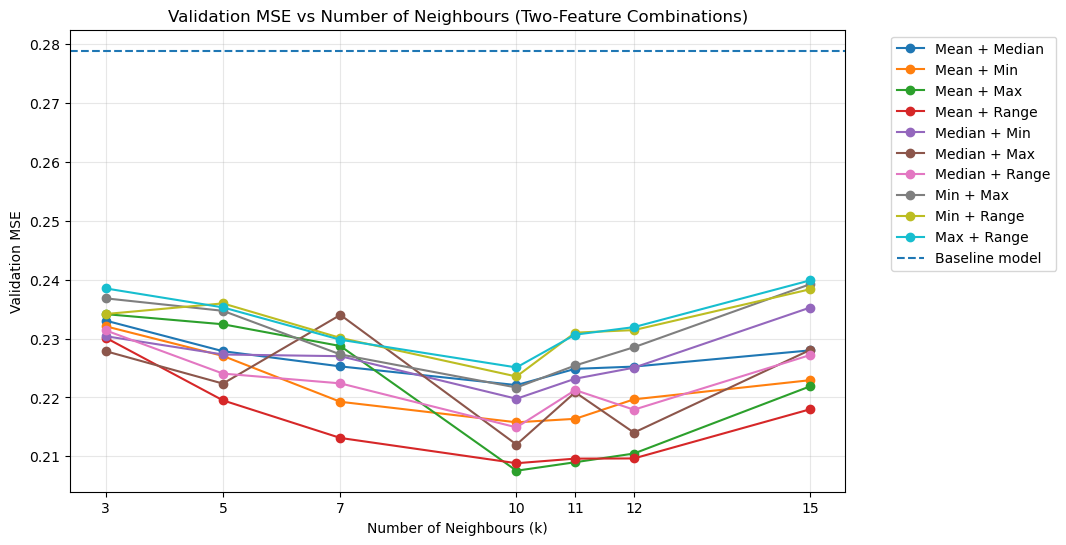

In [31]:
# ============================================================
# Figure 2: Validation MSE vs number of neighbours (k)
# All 2-feature combinations
# ============================================================

plt.figure(figsize=(10, 6))

for combo_name in results_k_feature_df["combo"].unique():
    subset = results_k_feature_df[
        results_k_feature_df["combo"] == combo_name
    ].sort_values("k")

    plt.plot(
        subset["k"],
        subset["val_mse"],
        marker="o",
        label=combo_name
    )

baseline_val_mse = mean_squared_error(y_val, model.predict(X_val))

plt.axhline(
    y=baseline_val_mse,
    linestyle="--",
    label="Baseline model"
)

plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Validation MSE")
plt.title("Validation MSE vs Number of Neighbours (Two-Feature Combinations)")
plt.xticks(sorted(results_k_feature_df["k"].unique()))
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()